![Banner](../../images/02_banner.png)


# 2.5 Local Spatial Autocorrelation (LISA)

**Part:** 2 — Spatial Autocorrelation (Chapter 2.5 of 6)

**Dataset:** `diabetes_northeast.shp` (217 counties)

**Focus:** Local Moran's I (LISA), two competing permutation schemes, multiple-testing correction, cluster mapping, and bivariate LMI clusters

**Library:** `spatialstats.esda`, `spatialstats.cluster`, `spatialstats.viz` (PySpatialStats)


***

## Table of Contents

1. [Overview](#1.-Overview)

2. [Python Setup](#2.-Python-Setup)

3. [Local Moran's I](#3.-Local-Moran's-I)

4. [Inference: Two Different Permutation Schemes](#4.-Inference:-Two-Different-Permutation-Schemes)

   - 4.1 [esda.Moran_Local: unconditional permutation, and a default that hides everything](#4.1-esda.Moran_Local:-unconditional-permutation,-and-a-default-that-hides-everything)

   - 4.2 [cluster.local_moran_clusters: conditional permutation](#4.2-cluster.local_moran_clusters:-conditional-permutation)

   - 4.3 [The FDR resolution limit](#4.3-The-FDR-resolution-limit)

   - 4.4 [Recommended workflow](#4.4-Recommended-workflow)

5. [Mapping LISA Clusters](#5.-Mapping-LISA-Clusters)

6. [Companions: Local Geary and Getis-Ord Gi/Gi*](#6.-Companions:-Local-Geary-and-Getis-Ord-Gi/Gi*)

7. [Bivariate LMI Clusters](#7.-Bivariate-LMI-Clusters)

8. [Summary and Conclusions](#8.-Summary-and-Conclusions)

9. [Resources](#9.-Resources)


***
## 1. Overview

Chapter 2.4's statistics each collapse the whole map into a single number. **Local indicators of spatial
association (LISA)** do the opposite: one statistic *per region*, each testable in its own right, showing
*where* — not just *whether* — clustering happens.

| Step | What we do |
|------|------------|
| Local Moran's I | Decompose global Moran's I into 217 per-county contributions |
| Inference | Contrast this library's two permutation schemes for local significance, and a default setting that silently reports zero significant counties despite an unambiguous global signal |
| Multiple testing | Apply and stress-test Benjamini–Hochberg FDR correction, including its resolution limit |
| Mapping | Turn a LISA result into a cluster map, read alongside the choropleth and Moran scatterplot |
| Companions | Local Geary and Getis-Ord Gi/Gi* as related, though not fully treated until Part 4, local statistics |
| Bivariate LMI | Locate counties where diabetes is high or low among neighbours that are high or low on six covariates |

**A concrete warning up front, quantified below:** with this library's default settings, `Moran_Local` on
`Dia_pct` reports **zero** significant counties — even though Chapter 2.4 found global Moran's I significant
at $p_\text{sim} = 0.001$. That is not a contradiction; it is a specific, explainable consequence of combining
999 permutations with FDR correction on 217 simultaneous tests, and this chapter works through exactly why.


***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.weights import Queen
from spatialstats.esda import Moran, MoranBV, Moran_Local, Moran_Local_BV, Geary_Local, G_Local
from spatialstats.cluster import local_moran_clusters
from spatialstats.viz import choropleth, moran_scatter, lisa_cluster_map

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
     "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

counties = gpd.read_file(DATA / "diabetes_northeast.shp")
w = Queen(counties)
global_moran = Moran(counties["Dia_pct"], w, permutations=999, seed=1)
print(f"spatialstats : version {spatialstats.__version__}")
print(f"global Moran's I = {global_moran.I:.4f}, p_sim = {global_moran['p_sim']:.4f}  (for reference throughout)")


spatialstats : version 0.2.0
global Moran's I = 0.2398, p_sim = 0.0010  (for reference throughout)


***
## 3. Local Moran's I

For each region $i$, with $z_i = y_i - \bar y$ and $m_2 = \frac{1}{n}\sum_i z_i^2$:

$$
I_i = \frac{z_i}{m_2} \sum_j w_{ij} z_j.
$$

Summing $I_i$ over all $i$ (up to a constant) recovers the global Moran's I of Chapter 2.4 — local Moran's I is
a genuine decomposition, not just a related statistic computed separately.

In [2]:
lm = Moran_Local(counties["Dia_pct"], w, permutations=999, seed=1)  # default fdr=True
frame = lm.to_frame()
frame.index = counties["COUNTY"]
print(f"sum of Ii / n vs. global I: {frame['Ii'].sum() / len(frame):.4f}  vs.  {global_moran.I:.4f}")
frame.sort_values("Ii", ascending=False).head(6)

sum of Ii / n vs. global I: 0.2387  vs.  0.2398


,Ii,p_sim,q,label,p_adjusted
COUNTY,,,,,
Niagara County,2.331651,0.007,0,NS,0.204235
Salem County,2.322336,0.013,0,NS,0.204235
Orleans County,2.244245,0.005,0,NS,0.204235
Camden County,2.138813,0.008,0,NS,0.204235
Dukes County,2.048541,0.060,0,NS,0.390600
Washington County,1.932872,0.002,0,NS,0.204235


***
## 4. Inference: Two Different Permutation Schemes

A $p$-value for $I_i$ needs a null distribution, and there are two defensible ways to build one by permutation
— this library implements **both**, in two different places, and they do not agree.

### 4.1 `esda.Moran_Local`: unconditional permutation, and a default that hides everything

`esda.Moran_Local`'s permutation scheme reshuffles **the entire vector** $y$ for each replicate (including
region $i$ itself), recomputing $I_i$ every time. Its default also applies **Benjamini–Hochberg FDR
correction** across all 217 simultaneous tests (`fdr=True`).

In [3]:
lm_default = Moran_Local(counties["Dia_pct"], w, permutations=999, seed=1)          # fdr=True (default)
lm_raw = Moran_Local(counties["Dia_pct"], w, permutations=999, seed=1, fdr=False)    # fdr=False

n_sig_default = int(np.sum(lm_default.labels != "NS"))
n_sig_raw = int(np.sum(lm_raw.labels != "NS"))
print(f"fdr=True  (library default): {n_sig_default} significant counties")
print(f"fdr=False (raw p_sim <= 0.05): {n_sig_raw} significant counties")
import collections
print("fdr=False breakdown:", dict(collections.Counter(lm_raw.labels[lm_raw.labels != 'NS'])))

fdr=True  (library default): 0 significant counties
fdr=False (raw p_sim <= 0.05): 29 significant counties
fdr=False breakdown: {'LL': 10, 'HH': 16, 'HL': 1, 'LH': 2}


**Zero.** With the library's own default arguments, not a single county is flagged as a significant LISA
cluster — despite global Moran's I being unambiguous ($p_\text{sim}=0.001$). Turning off FDR correction
recovers 29 significant counties (16 HH, 10 LL, 2 LH, 1 HL), matching what a naive look at the Moran scatterplot
(Chapter 2.3) would suggest. **This is not a bug — it is 217 simultaneous hypothesis tests being corrected
honestly** — but it means the single most natural first call (`Moran_Local(y, w)`) silently reports "nothing
significant" for a dataset with a strong, real spatial signal, unless the analyst either turns `fdr=False` or
increases `permutations` enough (Section 4.3) for FDR to have room to flag anything at all.

### 4.2 `cluster.local_moran_clusters`: conditional permutation

The statistically more defensible scheme for a *local* test holds $y_i$ fixed and resamples only its
neighbours' values from the other $n-1$ observations — the **conditional permutation** appropriate to a
statistic about one region's relationship to its neighbourhood, implemented separately in
`spatialstats.cluster.local_moran_clusters`.

In [4]:
lmc_nofdr = local_moran_clusters(counties["Dia_pct"], w, permutations=999, seed=1, correction="none")
lmc_fdr = local_moran_clusters(counties["Dia_pct"], w, permutations=999, seed=1, correction="fdr")

n_nofdr = int(np.sum(lmc_nofdr.labels != "Not significant"))
n_fdr = int(np.sum(lmc_fdr.labels != "Not significant"))
print(f"conditional permutation, no correction (p<=0.05): {n_nofdr} significant")
print("  breakdown:", dict(collections.Counter(lmc_nofdr.labels[lmc_nofdr.labels != 'Not significant'])))
print(f"conditional permutation, FDR, 999 permutations:    {n_fdr} significant")

conditional permutation, no correction (p<=0.05): 30 significant
  breakdown: {'LL': 11, 'HL': 2, 'HH': 13, 'LH': 4}
conditional permutation, FDR, 999 permutations:    0 significant


/tmp/ipykernel_37847/3783624526.py:2: UserWarning: With 999 permutations the smallest attainable p-value is 0.002, so at least 9 of 217 areas would have to sit at that minimum to survive FDR at alpha=0.05; few or no clusters may be detected. Use more permutations (>= 8680) or inference='analytic' (Gi*).
  lmc_fdr = local_moran_clusters(counties["Dia_pct"], w, permutations=999, seed=1, correction="fdr")


Uncorrected, the conditional scheme flags 30 counties — close to, but not identical to, `esda`'s uncorrected 29
(different resampling schemes give slightly different p-values for the same $I_i$). With FDR at the same 999
permutations, it *also* collapses to zero, for the reason explored next.

### 4.3 The FDR resolution limit

Benjamini–Hochberg FDR compares each test's p-value against a threshold that depends on its rank among all
tests. With $m$ permutations, the smallest **attainable** two-sided local p-value is $2/(m+1)$ (Chapter 2.4's
single-test floor, doubled for a two-tailed local test) — and FDR needs enough distinct achievable p-values
below that resolution to have room to flag *anything* at $n=217$ simultaneous tests.

In [5]:
for m in (999, 2999, 4999, 6999, 8999, 9999):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        lmc_m = local_moran_clusters(counties["Dia_pct"], w, permutations=m, seed=1, correction="fdr")
    n_sig = int(np.sum(lmc_m.labels != "Not significant"))
    print(f"m={m:5d}  (p-floor={2/(m+1):.5f})  ->  {n_sig} significant after FDR")

m=  999  (p-floor=0.00200)  ->  0 significant after FDR


m= 2999  (p-floor=0.00067)  ->  0 significant after FDR


m= 4999  (p-floor=0.00040)  ->  0 significant after FDR


m= 6999  (p-floor=0.00029)  ->  0 significant after FDR


m= 8999  (p-floor=0.00022)  ->  0 significant after FDR


m= 9999  (p-floor=0.00020)  ->  1 significant after FDR


Not until **9,999 permutations** does even a single county survive FDR correction here (one HH cluster) — an
order of magnitude more computation than the library's own default of 999, just to let the multiple-testing
correction have room to operate at all on $n=217$. This is a structural property of combining permutation
inference with FDR at moderate $n$, not something specific to this dataset; Chapter 2.6, Exercise 4 asks you to
reproduce this search.

### 4.4 Recommended workflow

Given the above, this Part's working recommendation — consistent with how `esda.G_Local` handles the same
tension by defaulting to `inference='analytic'` (Part 4) — is:

1. Use `esda.Moran_Local` (with `fdr=False`) to get $I_i$, the quadrant assignment, and a quick raw-significance
   screen.
2. Use `cluster.local_moran_clusters` for the properly conditional permutation p-values and (if the permutation
   budget allows) FDR correction.
3. Always report **both** the raw and FDR-adjusted maps side by side (Section 5) — a raw-only map overstates
   how many counties are individually distinguishable from noise; an FDR-only map at a modest permutation count
   understates real local structure.

***
## 5. Mapping LISA Clusters

A three-panel view — the choropleth (what), the Moran scatterplot (how strong, overall), and the LISA cluster
map (where, county by county) — is the standard way to present this chapter's results together.

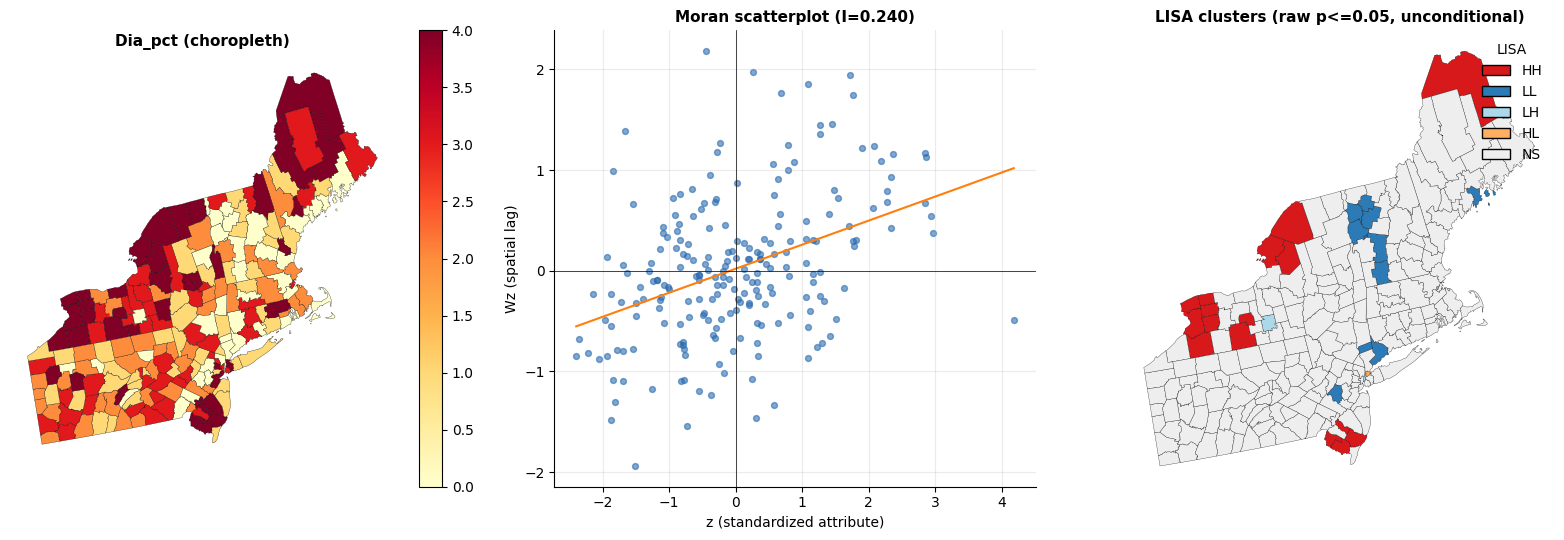

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
choropleth(counties, "Dia_pct", scheme="quantiles", k=5, ax=axes[0], cmap="YlOrRd")
axes[0].set_title("Dia_pct (choropleth)")

moran_scatter(global_moran, ax=axes[1], color=C["blue"], alpha=0.6, s=18)
axes[1].set_title(f"Moran scatterplot (I={global_moran.I:.3f})")

lisa_cluster_map(lm_raw, gdf=counties, ax=axes[2])
axes[2].set_title("LISA clusters (raw p<=0.05, unconditional)")
plt.tight_layout()
plt.show()

The HH cluster (red) sits in the lower-left of the map, overlapping the highest-prevalence quantile class in
the choropleth; the LL cluster (blue) sits in the north. The handful of HL/LH counties (orange/light blue) are
scattered singly rather than forming their own regions — consistent with them being local contrasts rather than
a second, distinct spatial regime.

***
## 6. Companions: Local Geary and Getis-Ord Gi/Gi*

Two related local statistics exist in `esda`, with their full treatment (hot-spot-specific workflow,
statistical calibration, FDR sensitivity) deferred to Part 4:

- **`Geary_Local`** — the local decomposition of Geary's C, sensitive to local dissimilarity rather than
  Moran's local product; useful for spotting *dissimilar-neighbour* outliers even where Local Moran's quadrant
  assignment does not distinguish HL from LH clearly.
- **`G_Local`** (Gi / Gi\*) — specifically tests *high-value* clustering around each region (`star=False`
  excludes the region itself from its own neighbourhood sum; `star=True` includes it).

One concrete caveat worth carrying forward to Part 4: `G_Local(star=False)` (Gi, self excluded) is undefined
for the one-county island in this data — it has no neighbours to sum over — and the permutation machinery does
not fail loudly when that happens.

In [7]:
island_idx = w.islands()[0]
gi = G_Local(counties["Dia_pct"], w, star=False, permutations=999, seed=1, fdr=False)
gis = G_Local(counties["Dia_pct"], w, star=True, permutations=999, seed=1, fdr=False)
print(f"Nantucket (island) Gi  (self excluded): statistic={gi.Gs[island_idx]}, p_sim={gi.p_sim[island_idx]:.4f}")
print(f"Nantucket (island) Gi* (self included): statistic={gis.Gs[island_idx]:.4f}, p_sim={gis.p_sim[island_idx]:.4f}")

Nantucket (island) Gi  (self excluded): statistic=nan, p_sim=0.0010
Nantucket (island) Gi* (self included): statistic=-1.0833, p_sim=0.2840


`Gi` for the island comes back as `NaN` (correctly — the statistic is genuinely undefined with zero neighbours),
but its permutation p-value is reported as **0.001**, i.e. apparently highly significant. This happens because
the permutation comparison `|simulated| >= |NaN|` evaluates to `False` for every single replicate under NumPy's
comparison rules, so *no* simulated value ever counts as "as extreme", and the p-value formula's numerator stays
at its minimum. A `NaN` statistic should never be reported with a small p-value; `Gi*` (which includes the
region itself and is therefore always defined) is the safer default whenever a graph may contain islands — Part
4 covers this in full alongside the rest of the hot-spot toolkit.

***
## 7. Bivariate LMI Clusters

Chapter 2.4's `MoranBV` collapses two variables into one number: the association between variable $x$ at county
$i$ and variable $y$ at $i$'s neighbours. **Bivariate local Moran's I** keeps a statistic for every county.
With both variables standardised,

$$
I_i^{xy} = z_{x,i} \sum_j w_{ij} z_{y,j}.
$$

Throughout this section $x$ is `Dia_pct` and $y$ is one covariate, so each quadrant reads **diabetes at the
county** against **the covariate in the neighbourhood**:

| Label | Diabetes at $i$ | Covariate among neighbours |
|---|---|---|
| HH | above average | above average |
| LL | below average | below average |
| HL | above average | below average |
| LH | below average | above average |

`Moran_Local_BV` holds diabetes at $i$ fixed and redraws the neighbours' covariate values from the other
counties — the conditional permutation of Section 4.2. Section 4.3's FDR resolution limit still applies at
999 permutations and $n = 217$, so the maps use the raw $p \le 0.05$ screen (`fdr=False`), the same screen
as the univariate map in Section 5. `MoranBV` is printed beside the cluster counts so the local map can be
read against the single global number.

Obesity, physical inactivity, access to exercise, and the food environment index are fields on
`diabetes_northeast.shp`. Poverty and education are not. They are joined on `FIPS` from
`data/chr2024_poverty_education.csv` (County Health Rankings 2024): **children in poverty (%)** and
**high-school completion (%)**.


In [8]:
ses = pd.read_csv(DATA / "chr2024_poverty_education.csv")
g = counties.merge(ses, on="FIPS", how="left")
if g[["Poverty", "Education"]].isna().any().any():
    raise ValueError("Poverty or Education is missing after the FIPS join.")
w_bv = Queen(g)

pairs = [
    ("(a) Obesity", "Obesity"),
    ("(b) Physical inactivity", "PhysInact"),
    ("(c) Access to exercise", "Acc_Exer"),
    ("(d) Food environment index", "FoodEnvIdx"),
    ("(e) Poverty", "Poverty"),
    ("(f) Education", "Education"),
]

rows = []
bv = {}
for title, col in pairs:
    res = Moran_Local_BV(g["Dia_pct"], g[col], w_bv, permutations=999, seed=1, fdr=False)
    bv[col] = res
    counts = pd.Series(res.labels).value_counts()
    mbv = MoranBV(g["Dia_pct"], g[col], w_bv, permutations=999, seed=1)
    rows.append({
        "covariate": title,
        "MoranBV": mbv.I,
        "p_sim": mbv.p_value,
        "HH": int(counts.get("HH", 0)),
        "LL": int(counts.get("LL", 0)),
        "HL": int(counts.get("HL", 0)),
        "LH": int(counts.get("LH", 0)),
    })

bv_table = pd.DataFrame(rows).set_index("covariate")
bv_table.round(4)


,MoranBV,p_sim,HH,LL,HL,LH
covariate,,,,,,
(a) Obesity,0.5344,0.001,13,7,7,3
(b) Physical inactivity,0.6123,0.001,11,7,0,6
(c) Access to exercise,-1.0991,0.067,18,8,16,22
(d) Food environment index,-0.0664,0.001,7,5,9,11
(e) Poverty,0.7535,0.001,6,13,5,8
(f) Education,-0.2486,0.030,4,8,4,16


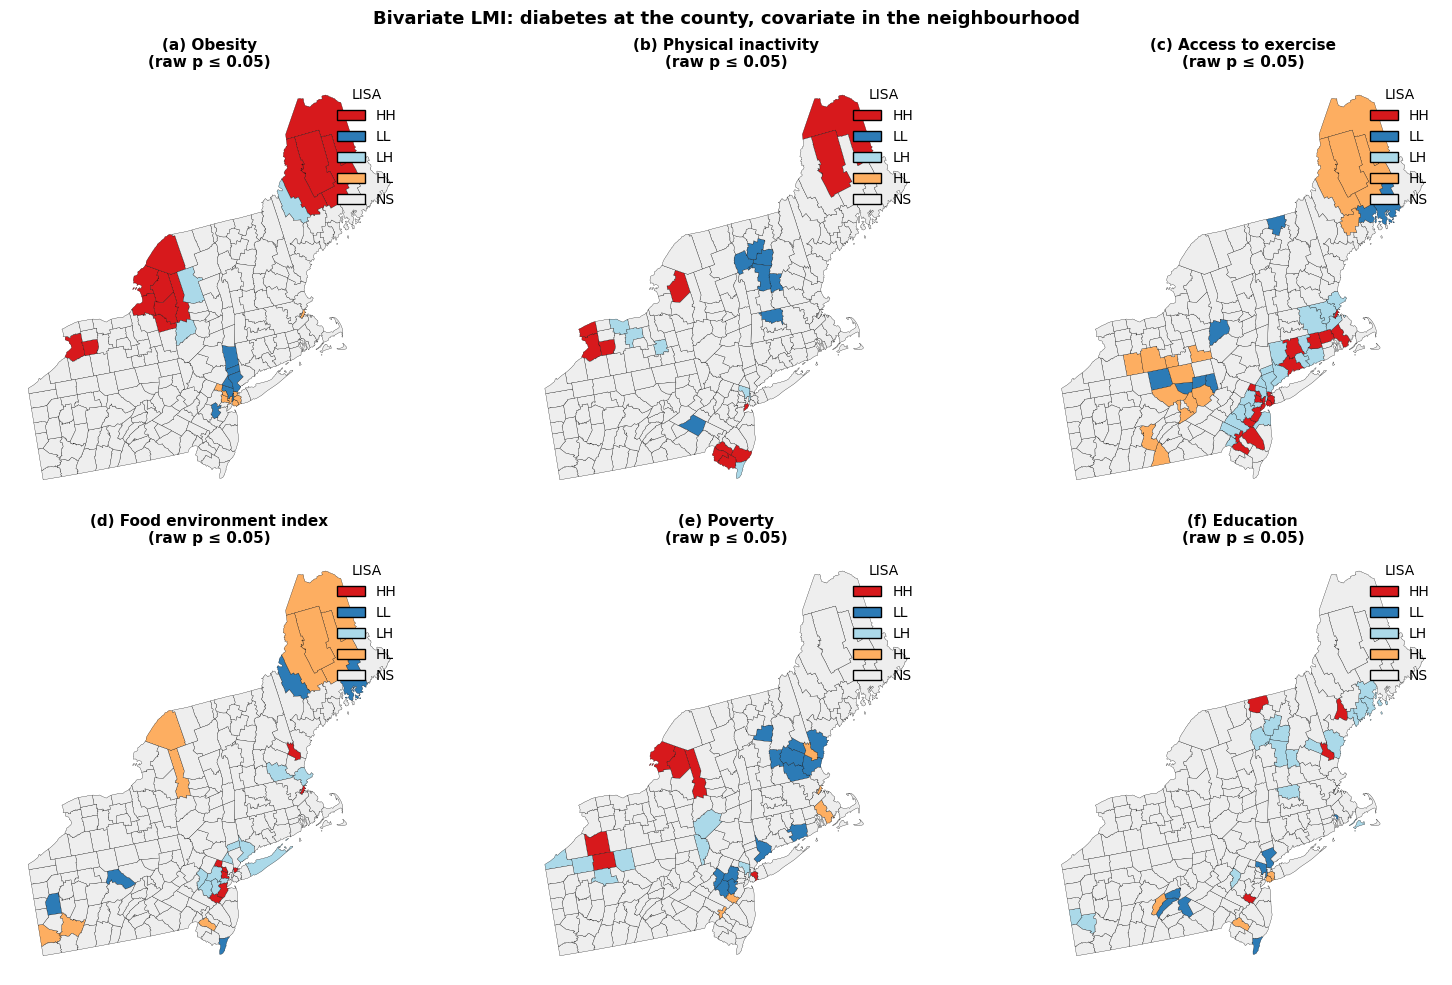

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (title, col) in zip(axes.ravel(), pairs):
    lisa_cluster_map(bv[col], gdf=g, ax=ax)
    ax.set_title(f"{title}\n(raw p ≤ 0.05)")
fig.suptitle("Bivariate LMI: diabetes at the county, covariate in the neighbourhood", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


Obesity and physical inactivity move with diabetes in the same direction (same-county correlations in
this file are about 0.68 and 0.82). Their cluster maps are mostly **HH and LL**: 13 high-diabetes counties
sit among high-obesity neighbours and 11 among high-inactivity neighbours, with matching low-low groups of
7 counties each. Physical inactivity contributes no HL counties at this threshold. Both global bivariate
tests are positive and clear (`MoranBV` about 0.53 and 0.61, $p_\text{sim} = 0.001$).

Access to exercise is the crowded map: **64** counties, spread across all four quadrants (18 HH, 8 LL,
16 HL, 22 LH). The same-county correlation with diabetes is weak (about −0.13), and the global bivariate
statistic is large in magnitude (`MoranBV` about −1.10) but only marginal ($p_\text{sim} = 0.067$). The
local screen is flagging scattered contrasts. That is the multiple-testing lesson of Section 4 applied to a
second variable: an uncorrected $p \le 0.05$ map overstates how many of those counties are individually
distinguishable from noise.

The food environment index and high-school completion run the other way. Global `MoranBV` is negative for
both (about −0.07 and −0.25). Locally, HL and LH outnumber HH and LL for the food environment (9 and 11,
against 7 and 5), and **LH** is the largest education class: 16 low-diabetes counties surrounded by
high completion.

Child poverty is positively associated with neighbouring diabetes (`MoranBV` about 0.75, $p_\text{sim} = 0.001$).
The largest local class is **LL** (13 counties): low diabetes surrounded by low child poverty. The HH class
is smaller (6). A positive global association can be carried by the low-low side of the map.


***
## 8. Summary and Conclusions

This chapter decomposed the single global Moran's I from Chapter 2.4 into 217 local statistics, and spent most
of its effort on the inference machinery around them — because that machinery, more than the statistic itself,
determines what gets reported.

### What we did

1. Computed Local Moran's I and confirmed it decomposes the global statistic exactly.
2. Compared `esda.Moran_Local`'s unconditional permutation scheme against `cluster.local_moran_clusters`'s
   conditional scheme, and found the library's own default (`fdr=True`, 999 permutations) reports **zero**
   significant counties for a dataset with an unambiguous global signal.
3. Traced that result to the FDR resolution limit: with 217 simultaneous tests, FDR correction needs roughly
   9,999 permutations before even one county can survive it at this dataset's effect size.
4. Settled on a two-step recommended workflow: `esda.Moran_Local` for quadrants and a quick raw screen,
   `cluster.local_moran_clusters` for defensible conditional-permutation significance.
5. Built a three-panel choropleth / Moran-scatterplot / LISA-cluster-map figure.
6. Introduced `Geary_Local` and `G_Local` as companions, and found a second real hazard: `Gi` (self-excluded)
   returns `NaN` for an island but a deceptively small p-value of 0.001 — never trust a p-value attached to a
   `NaN` statistic.
7. Mapped bivariate local Moran clusters of diabetes against obesity, physical inactivity, access to exercise,
   the food environment index, child poverty, and high-school completion.

### Practical takeaways

- **Never run `Moran_Local(y, w)` with its bare defaults and report "no clusters found" without checking
  `fdr=False` first** — the default can hide a real, strong pattern behind an under-powered multiple-testing
  correction.
- Local and global tests can legitimately disagree in *emphasis* (which counties, individually) while agreeing
  in substance (yes, there is spatial structure) — that is what decomposition means, not a contradiction to
  resolve.
- A `NaN` local statistic (islands, zero-variance neighbourhoods) needs its own check before its accompanying
  p-value is trusted at all.
- Read a bivariate cluster as diabetes *at the county* against the covariate *in the neighbourhood*. HH and LL
  are concordance; HL and LH are local contrasts. A covariate whose global bivariate test is marginal
  (access to exercise) can still light up many counties on an uncorrected local screen.

### Next steps

**Chapter 2.6 (Sensitivity, Pitfalls and Exercises)** closes Part 2 by systematically varying weights,
permutation counts, and correction choices — quantifying exactly how much of this Part's conclusions survive
those choices — and by working five solved exercises that draw on every chapter so far.


***
## 9. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Anselin, L. (1995). Local indicators of spatial association — LISA. *Geographical Analysis*, 27, 93–115. | The original LISA paper; defines the local Moran decomposition used here |
| Anselin, L., Syabri, I. & Smirnov, O. (2002). Visualizing multivariate spatial correlation with dynamically linked windows. In *New Tools for Spatial Data Analysis*. | Bivariate LISA: one variable at a place against the spatial lag of another |
| Benjamini, Y. & Hochberg, Y. (1995). Controlling the false discovery rate. *JRSS B*, 57, 289–300. | Origin of the FDR correction applied throughout this chapter |
| Ord, J. K. & Getis, A. (1995). Local spatial autocorrelation statistics: distributional issues and an application. *Geographical Analysis*, 27, 286–306. | Local Gi/Gi* statistics, fully treated in Part 4 |

### Key papers

| Paper | Contribution |
|---|---|
| de Castro, M. C. & Singer, B. H. (2006). Controlling the false discovery rate: a new application to account for multiple and dependent tests in local statistics of spatial association. *Geographical Analysis*, 38, 180–208. | FDR correction specifically for LISA, and its resolution-limit issue explored in Section 4.3 |
| Boots, B. (2003). Developing local measures of spatial association for categorical data. *Journal of Geographical Systems*, 5, 139–160. | Local statistics for categorical (rather than continuous) attributes |

### In this library

| Object | Role |
|---|---|
| `spatialstats.esda.Moran_Local` | Local Moran's I with unconditional permutation; `fdr=True` by default |
| `spatialstats.esda.Moran_Local_BV` | Bivariate local Moran's I; conditional permutation of the lagged variable; `fdr=True` by default |
| `spatialstats.cluster.local_moran_clusters` | Local Moran's I with conditional permutation, the statistically preferred inference scheme |
| `spatialstats.esda.Geary_Local`, `G_Local` | Companion local statistics, fully developed in Part 4 |
| `spatialstats.viz.lisa_cluster_map` | HH/LL/HL/LH cluster maps |
| Part 4 | Full hot-spot and cluster-detection workflow, including calibrated Gi*/Gi and comparison across methods |
